### Import necessary libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from sklearn.utils import shuffle
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import glob
import cv2

### Load Dataset

In [3]:
with_mask=glob.glob('with_mask 1/with_mask 1/*.*')
without_mask=glob.glob('without_mask/without_mask/*.*')

In [4]:
print(len(with_mask))
print(len(without_mask))

1792
1792


### Reading images and labels

In [5]:
images=[]
labels=[]

for i in with_mask:
    img=cv2.imread(i)
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    img=cv2.resize(img,(64,64))
    images.append(img)
    labels.append(0)

for i in without_mask:
    img=cv2.imread(i)
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    img=cv2.resize(img,(64,64))
    images.append(img)
    labels.append(1)

In [6]:
len(images)

3584

### Visualizing some of the images

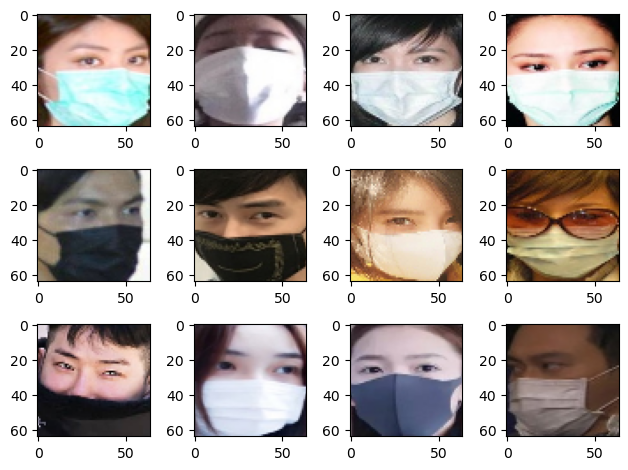

In [7]:
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(images[i])
plt.tight_layout()
    

### Splitting features and targets

In [8]:
x=np.array(images)
y=np.array(labels)

### Shuffling the images and labels

In [9]:
images,labels=shuffle(images,labels,random_state=42)

In [10]:
x.shape

(3584, 64, 64, 3)

In [11]:
y.shape

(3584,)

### Train test split

In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

### Model Selection

In [13]:
model=keras.models.Sequential([
    keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(64,64,3)),
    keras.layers.MaxPool2D(),

    keras.layers.Conv2D(64,(3,3),activation='relu'),
    keras.layers.MaxPool2D(),

    keras.layers.Flatten(),

    keras.layers.Dense(64,activation='relu'),

    keras.layers.Dense(1,activation='sigmoid')

    
])

C:\Users\AnjanaK\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         802,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 822,337 (3.14 MB)

 Trainable params: 822,337 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

### Training

In [16]:
model.fit(x_train,y_train,epochs=10,validation_split=0.2,batch_size=32)

Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 12s 101ms/step - accuracy: 0.8085 - loss: 15.8731 - val_accuracy: 0.9129 - val_loss: 0.2561
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - accuracy: 0.9420 - loss: 0.1771 - val_accuracy: 0.9390 - val_loss: 0.1884
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - accuracy: 0.9507 - loss: 0.1294 - val_accuracy: 0.9146 - val_loss: 0.3224
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - accuracy: 0.9634 - loss: 0.0987 - val_accuracy: 0.9460 - val_loss: 0.2115
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - accuracy: 0.9860 - loss: 0.0458 - val_accuracy: 0.9373 - val_loss: 0.2260
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - accuracy: 0.9948 - loss: 0.0244 - val_accuracy: 0.9425 - val_loss: 0.2886
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - accuracy: 0.9913 - loss: 0.0323 - val_accuracy: 0.9216 - val_loss: 0.3552
Epoch 8/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - accuracy: 0.9900 - loss: 0.0310 - val_accuracy: 0.9

### Prediction

In [17]:
prediction=model.predict(x_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step 


In [18]:
pred=[]

for i in prediction:
    if i>0.5:
        pred.append(1)
    else:
        pred.append(0)

In [19]:
label_dict={0:'with mask',1:'without mask'}

### Evaluation metrics

In [20]:
accuracy_score(y_test,pred)

0.9511854951185496

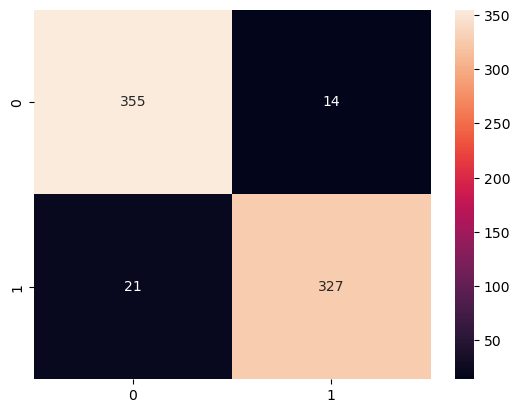

In [21]:
sns.heatmap(confusion_matrix(y_test,pred),annot=True,fmt='d')
plt.show()

In [22]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       369
           1       0.96      0.94      0.95       348

    accuracy                           0.95       717
   macro avg       0.95      0.95      0.95       717
weighted avg       0.95      0.95      0.95       717



### Visualizing some of the predictions 

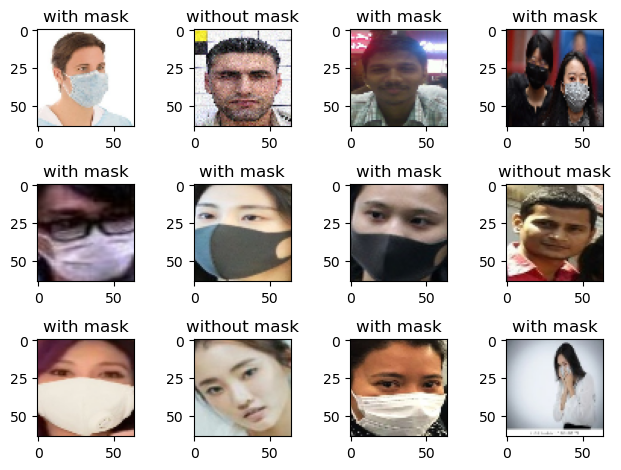

In [23]:
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(x_test[i])
    plt.title(label_dict[pred[i]])
plt.tight_layout()
    

In [32]:
img1=plt.imread('img1.jpg')


In [33]:
img1=cv2.resize(img1,(64,64))


In [38]:
img1=np.array(img1)
img1=np.reshape(img1,(1,64,64,3))

In [39]:
prediction=model.predict(img1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


In [40]:
pred=[]

for i in prediction:
    if i>0.5:
        pred.append(1)
    else:
        pred.append(0)

In [45]:
pred

[1]

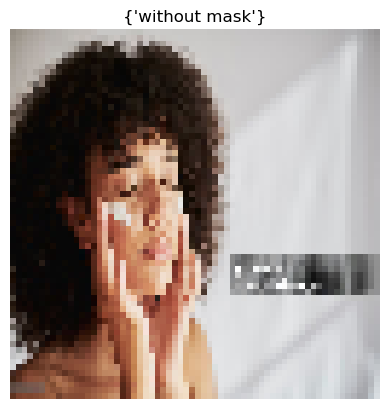

In [51]:
plt.imshow(img1[0])
plt.title({label_dict[pred[0]]})
plt.axis("off")
plt.show()